In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

from hurricane_ml.visualization import plot_hurricane

In [2]:
data = pd.read_csv("../data/ibtracs.NA.list.v04r01.csv", skiprows=[1], low_memory=False)
hurricane_df = data.drop(data[data["SEASON"] < 1980].index)

hurricane_df = hurricane_df.replace(r"^\s*$", np.nan, regex=True)

hurricane_df = hurricane_df.drop(columns=hurricane_df.columns[(hurricane_df.isna().sum() / len(hurricane_df) > 0.5)])
hurricane_df = hurricane_df.drop(columns=["USA_LAT", "USA_LON", "WMO_WIND"])

hurricane_df = hurricane_df.astype(
    {
        "SID" : "string",
        "SEASON" : "Int16",
        "NUMBER" : "Int16",
        "NAME" : "string",
        "ISO_TIME" : "datetime64[ns]",
        "NATURE" : "category",
        "LAT" : "float32",
        "LON" : "float32",
        "WMO_AGENCY" : "category",
        "TRACK_TYPE" : "category",
        "DIST2LAND" : "Int16",
        "LANDFALL" : "Int16",
        "IFLAG" : "category",
        "USA_AGENCY" : "category",
        "USA_ATCF_ID" : "string",
        "USA_STATUS" : "category",
        "USA_WIND" : "Int16",
        "USA_PRES" : "Int16",
        "USA_SSHS" : "category",
        "USA_POCI" : "Int16",
        "USA_ROCI" : "Int16",
        "USA_RMW" : "Int16",
        "STORM_SPEED" : "Int16",
        "STORM_DIR" : "Int16",
    }
)

hurricane_df["DELTA_LAT"] = hurricane_df.groupby("SID")["LAT"].diff().round(1)
hurricane_df["DELTA_LON"] = hurricane_df.groupby("SID")["LON"].diff().round(1)

hurricane_df["LAT_ACCELERATION"] = hurricane_df.groupby("SID")["DELTA_LAT"].diff().round(1)
hurricane_df["LON_ACCELERATION"] = hurricane_df.groupby("SID")["DELTA_LON"].diff().round(1)

hurricane_df["WIND_CHANGE"] = hurricane_df.groupby("SID")["USA_WIND"].diff()
hurricane_df["PRES_CHANGE"] = hurricane_df.groupby("SID")["USA_PRES"].diff()

hurricane_df["WIND_ACCELERATION"] = hurricane_df.groupby("SID")["WIND_CHANGE"].diff()
hurricane_df["PRES_ACCELERATION"] = hurricane_df.groupby("SID")["PRES_CHANGE"].diff()

hurricane_df["MONTH"] = hurricane_df["ISO_TIME"].dt.month.astype("Int16")

/tmp/ipykernel_69186/1951122089.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hurricane_df = hurricane_df.replace(r"^\s*$", np.nan, regex=True)


In [3]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=0
)

train_idx, test_idx = next(
    splitter.split(
        hurricane_df,
        groups=hurricane_df["SID"]
    )
)

train_df = hurricane_df.iloc[train_idx]
test_df = hurricane_df.iloc[test_idx]

test_df

,SID,SEASON,NUMBER,NAME,ISO_TIME,NATURE,LAT,LON,WMO_AGENCY,TRACK_TYPE,...,STORM_DIR,DELTA_LAT,DELTA_LON,LAT_ACCELERATION,LON_ACCELERATION,WIND_CHANGE,PRES_CHANGE,WIND_ACCELERATION,PRES_ACCELERATION,MONTH
85571,1980200N25270,1980,49,UNNAMED,1980-07-17 12:00:00,TS,25.000000,-90.000000,hurdat_atl,main,...,300,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,7
85572,1980200N25270,1980,49,UNNAMED,1980-07-17 15:00:00,TS,25.100000,-90.199997,NaN,main,...,300,0.1,-0.2,NaN,NaN,3,<NA>,<NA>,<NA>,7
85573,1980200N25270,1980,49,UNNAMED,1980-07-17 18:00:00,TS,25.200001,-90.400002,hurdat_atl,main,...,295,0.1,-0.2,0.0,0.0,2,<NA>,-1,<NA>,7
85574,1980200N25270,1980,49,UNNAMED,1980-07-17 21:00:00,TS,25.299999,-90.699997,NaN,main,...,295,0.1,-0.3,0.0,-0.1,0,<NA>,-2,<NA>,7
85575,1980200N25270,1980,49,UNNAMED,1980-07-18 00:00:00,TS,25.400000,-90.900002,hurdat_atl,main,...,305,0.1,-0.2,0.0,0.1,0,<NA>,0,<NA>,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126940,2025286N14320,2025,101,LORENZO,2025-10-15 00:00:00,TS,19.200001,-45.500000,hurdat_atl,main,...,0,0.5,0.0,0.1,0.2,0,0,0,0,10
126941,2025286N14320,2025,101,LORENZO,2025-10-15 03:00:00,TS,19.600000,-45.500000,NaN,main,...,10,0.4,0.0,-0.1,0.0,0,0,0,0,10
126942,2025286N14320,2025,101,LORENZO,2025-10-15 06:00:00,TS,20.100000,-45.299999,hurdat_atl,main,...,25,0.5,0.2,0.1,0.2,0,-1,0,-1,10
126943,2025286N14320,2025,101,LORENZO,2025-10-15 09:00:00,TS,20.600000,-45.000000,NaN,main,...,35,0.5,0.3,0.0,0.1,0,0,0,1,10


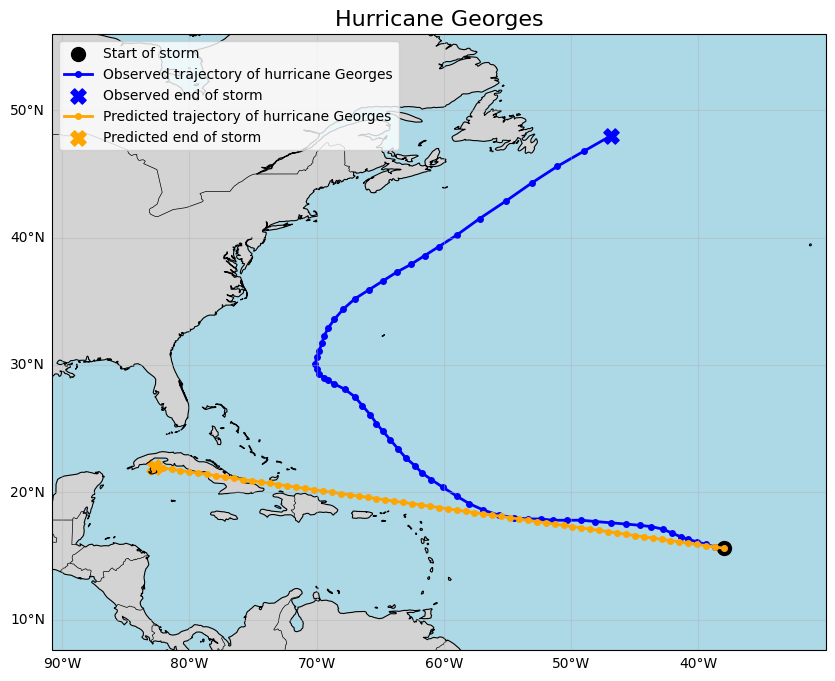

In [7]:
def predict_storm_linear(df_initial: pd.DataFrame, n_predictions: int):

    last_lon, last_lat = df_initial.iloc[-1]["LON"], df_initial.iloc[-1]["LAT"]
    last_delta_lon, last_delta_lat = df_initial.iloc[-1]["DELTA_LON"], df_initial.iloc[-1]["DELTA_LAT"]

    for i in range(1, n_predictions + 1):

        lon_prediction = last_lon + i * last_delta_lon
        lat_prediction = last_lat + i * last_delta_lat

        movement_prediction = pd.DataFrame({
            "LON": [lon_prediction],
            "LAT": [lat_prediction]
        })

        df_initial = pd.concat([df_initial, movement_prediction], ignore_index=True)

    return df_initial

first_hurricane = test_df[test_df["SID"] == test_df.iloc[50]["SID"]]

first_hurricane_prediction = predict_storm_linear(first_hurricane.iloc[0:2], len(first_hurricane))

plot_hurricane(first_hurricane, first_hurricane_prediction)